In [2]:
import numpy as np 
import pandas as pd

data = pd.read_csv('Instagram-datasets.csv')

df = pd.DataFrame(data)

#checking for null values
null = df["hashtag_comment"].isnull()
null_count = null.sum()

#filling the null values with the particular list
hashtag = ["#love", "#instagood", "#fashion", "#photoftheday", "#photgraphy", "#viral", "#india", "#trending", "#indianfoodie", "vlogger"]

random_choices = np.random.choice(hashtag, size = null_count, p = [0.05,0.15,0.025,0.175,0.1,0.1,0.1,0.080,0.12,0.1])

df.loc[null, "hashtag_comment"] = random_choices

In [17]:
#top trending hashtags
group = df["hashtag_comment"].value_counts().head(10)
print(group)

#most active users
active = df.groupby("comment_user")["comment"].count()
print("\n","\n",f" The Most active user is : {active.idxmax()}, with a total comment count of : {active.max()}")

#total likes
likes = df.groupby("comment_user")["likes_number"].sum()
print("\n","\n", likes)

#most popular posting time
df["comment_date"] = pd.to_datetime(df["comment_date"])
df["comment_time"] = df["comment_date"].dt.time

time = df["comment_time"].value_counts().idxmax()
print("\n \n","The popular posting time is: ", time)

hashtag_comment
#photoftheday    194
#instagood       147
#indianfoodie    137
#photgraphy      102
#india            92
#viral            90
vlogger           89
#trending         77
#love             48
#fashion          18
Name: count, dtype: int64

 
  The Most active user is : liv███nla███gas███, with a total comment count of : 6

 
 comment_user
1hljk             2
1sh███kyb███      3
201███l.l███      1
3be███23          1
3en███ili███      1
                 ..
zik███_ot███9     2
zin███vlo███      3
zji███i           1
zor███ske███es    1
zyn███            1
Name: likes_number, Length: 929, dtype: int64

 
 The popular posting time is:  21:05:51


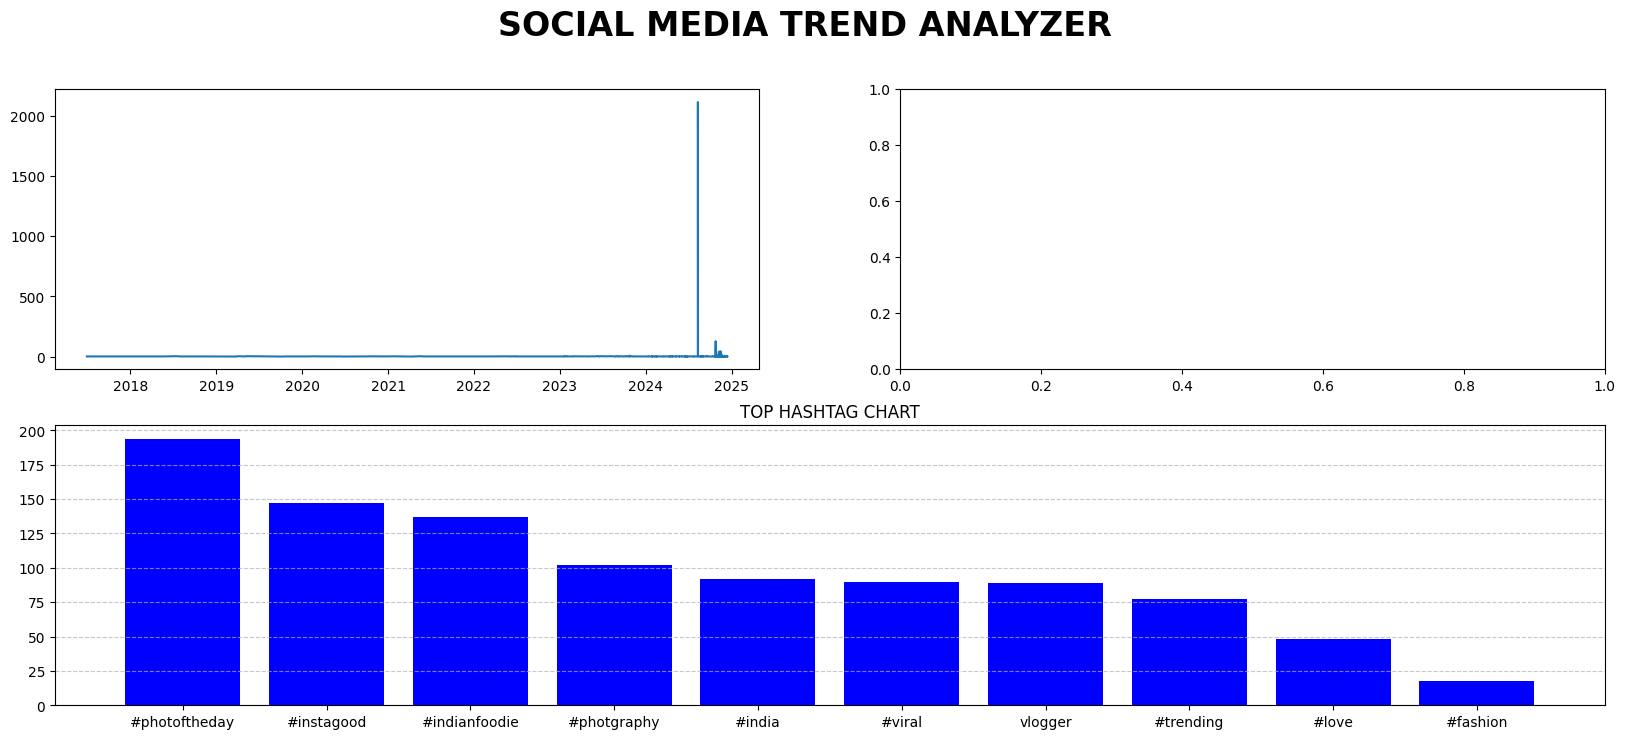

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

#VISUALIZATION

fig , axes = plt.subplot_mosaic([['l_top', 'r_top'],
                                  ['bottom', 'bottom']],
                                 figsize = (20,8))
plt.suptitle("SOCIAL MEDIA TREND ANALYZER",fontsize = 24, fontweight = "bold",y = 0.98)

#Top Hashtags Chart
axes['bottom'].bar(group.index, group.values, color = "blue")
axes['bottom'].set_title("TOP HASHTAG CHART")
axes['bottom'].grid(axis = 'y', alpha = 0.7, linestyle = "--")

#Daily Engagement Trend
df['comment_date'] = pd.to_datetime(df['comment_date'])
like_per_day = df.groupby("comment_date")['likes_number'].sum()
axes['l_top'].plot(like_per_day)